### 실습 1. 전처리 데이터 불러오기

해야 할 일

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [1]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 1. 전체 행과 컬럼 개수
print("\n====shape:=======")
print(df_books.shape)

# 2. 컬럼 이름
print("\n====columns:=======")
print(df_books.columns)

# 3. 앞의 5행
print("\n====앞의 5행:=======")
display(df_books.head())

# 4. 상품명 컬럼 존재 여부
print("\n====상품명 컬럼 존재 여부:=======")
print("상품명" in df_books.columns)


====shape:=======
(199, 8)

====columns:=======
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

====앞의 5행:=======


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설



====상품명 컬럼 존재 여부:=======
True


### 실행 결과

- `book_bestseller_clean.csv` 파일을 `df_books` DataFrame으로 정상적으로 불러왔다.
- 데이터 크기는 **199행, 8컬럼**으로 확인되었다.
- 컬럼은 `순위`, `판매상품ID`, `상품명`, `판매가`, `저자`, `출판사`, `발행일`, `분야`로 구성되어 있다.
- 앞의 5행 데이터가 정상적으로 출력되었다.
- `상품명` 컬럼 존재 여부를 확인한 결과 **True**로 확인되었다.

### 실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [2]:
df_books["상품명"].head(20)
df_books["상품명"].isna().sum()
titles = (

    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()

)

titles.head()


0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str

In [3]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 데이터 크기 확인
print("\n====shape:=======")
print(df_books.shape)

# 컬럼 이름 확인
print("\n====columns:=======")
print(df_books.columns)

# 앞의 5행 확인
print("\n====앞의 5행:=======")
display(df_books.head())

# 상품명 컬럼 존재 여부 확인
print("\n====상품명 컬럼 존재 여부:=======")
print("상품명" in df_books.columns)


====shape:=======
(199, 8)

====columns:=======
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

====앞의 5행:=======


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설



====상품명 컬럼 존재 여부:=======
True


### 상품명 데이터 탐색 결과 요약

- `book_bestseller_clean.csv` 파일을 정상적으로 불러왔다.
- 데이터 크기는 **199행, 8컬럼**으로 확인되었다.
- 분석에 필요한 `상품명` 컬럼이 포함되어 있다.
- 앞의 5행을 확인한 결과 상품명이 정상적으로 저장되어 있었다.
- `"상품명" in df_books.columns` 결과가 **True**로 확인되어, 이후 상품명 기반 단어 빈도 분석을 진행할 수 있는 상태이다.

### 실습 3. Dictionary로 단어 빈도 원리 이해하기 실습 전 이해하기
이번 실습은 여러 단어를 하나씩 확인하면서 **각 단어가 몇 번 나왔는지 세는 작업**이다.
같은 단어가 다시 나오면 기존 개수에 **1을 더하고**, 처음 나온 단어는 **1부터 시작**한다.
이 작업을 반복해서 최종적으로 **단어별 등장 횟수를 Dictionary에 저장**한다.

In [4]:
# 샘플 단어 목록
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터",
]

# 단어별 등장 횟수를 저장할 Dictionary
word_counts = {}

# 단어를 하나씩 확인하면서 개수 세기
for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1

# 결과 확인
print("\n====단어 빈도 결과:=======")
print(word_counts)


====단어 빈도 결과:=======
{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 단어 빈도 계산 결과

- `sample_words`의 단어를 하나씩 반복하면서 등장 횟수를 계산했다.
- 결과는 `{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}`로 확인되었다.
- `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 등장했다.
- Dictionary를 이용하면 단어별 등장 횟수를 저장하고 확인할 수 있다.

### 실습 4. Counter로 단어 빈도 계산하기

이번 실습에서는 `Counter`를 사용해 단어별 등장 횟수를 더 간단하게 계산한다.

- `Counter(sample_words)` → 각 단어의 빈도를 자동으로 계산
- `.most_common()` → 많이 나온 단어부터 확인
- `.most_common(3)` → 상위 3개 단어만 확인

Dictionary는 빈도 계산 원리를 직접 이해하기 좋고,  
Counter는 같은 작업을 더 짧고 편리하게 처리할 때 사용한다.

In [5]:
from collections import Counter

# 단어 빈도 계산
sample_counter = Counter(sample_words)

# 전체 단어 빈도 확인
print("\n====전체 단어 빈도:=======")
print(sample_counter)

# 많이 나온 순서대로 확인
print("\n====빈도순 정렬:=======")
print(sample_counter.most_common())

# 상위 3개 단어 확인
print("\n====상위 3개 단어:=======")
print(sample_counter.most_common(3))


====전체 단어 빈도:=======
Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})

====빈도순 정렬:=======
[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

====상위 3개 단어:=======
[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### Counter 단어 빈도 계산 결과

- `Counter`를 사용해 각 단어의 등장 횟수를 자동으로 계산했다.
- 전체 결과는 `데이터 3회`, `분석 2회`, `파이썬 1회`, `AI 1회`로 확인되었다.
- `most_common()`을 사용하면 등장 횟수가 많은 순서대로 정렬할 수 있다.
- `most_common(3)`으로 가장 많이 등장한 상위 3개 단어만 확인할 수 있다.

### 실습 5. pandas `value_counts()`로 빈도 확인하기

이번 실습에서는 pandas의 `value_counts()`를 이용해 각 단어가 몇 번 등장했는지 확인한다.

- `pd.Series(sample_words)` → 단어 목록을 Series로 변환
- `.value_counts()` → 같은 값이 몇 번 나왔는지 자동으로 계산
- 결과는 `Counter`로 계산한 빈도와 비슷하다.

### 세 방법 비교

| 방법 | 특징 | 의미 |
|---|---|---|
| Dictionary | 직접 빈도 누적 | 원리 이해 |
| Counter | Python 표준 기능 | 간단한 빈도 계산 |
| value_counts() | pandas 기능 | Series 기반 빈도 분석 |

분석 상황에 따라 가장 편한 방법을 선택해서 사용할 수 있다.

In [6]:
import pandas as pd

# 단어 목록을 Series로 변환
sample_series = pd.Series(sample_words)

# 단어별 빈도 확인
print("\n====value_counts 결과:=======")
print(sample_series.value_counts())


====value_counts 결과:=======
데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### value_counts() 단어 빈도 확인 결과

- `sample_words`를 pandas `Series`로 변환했다.
- `value_counts()`를 사용해 단어별 등장 횟수를 계산했다.
- 결과는 `데이터 3회`, `분석 2회`, `파이썬 1회`, `AI 1회`로 확인되었다.
- `Counter`와 비슷한 결과를 pandas에서도 간단하게 확인할 수 있었다.

### Counter와 value_counts() 비교

- 일반 Python 리스트 데이터 → `Counter`
- pandas의 DataFrame / Series 데이터 → `value_counts()`
- 대량 데이터를 pandas로 분석할 때는 `value_counts()`가 더 편리한 경우가 많다.

이번 교보문고 프로젝트에서는 pandas를 사용하고 있으므로 `value_counts()`를 사용하면 된다.

### 실습 6. 도서 제목을 간단하게 단어로 나누기

이번 실습에서는 실제 `상품명`을 정규표현식으로 간단하게 나누어 단어 목록을 만든다.

- 한글, 영어, 숫자만 추출해서 토큰으로 나눈다.
- 영어는 소문자로 바꿔서 같은 단어를 통일한다.
- 이렇게 만든 단어를 이용해 이후 빈도 분석을 할 수 있다.
- 다만 `시대의`, `python으로`처럼 의미 단위가 정확히 나뉘지 않을 수 있어, 이후 형태소 분석이 필요하다.

핵심 흐름은  
`상품명 → 단어로 나누기 → 단어 빈도 계산` 이다.

In [7]:
# 정규표현식 기능을 사용하기 위해 re 모듈 불러오기
import re

# 문자열을 간단하게 단어로 나누는 함수 만들기
def simple_tokenize(text):

    # 1. 입력된 값을 문자열로 바꾸기
    text = str(text)

    # 2. 영어 대문자를 소문자로 바꾸기
    text = text.lower()

    # 3. 한글, 영어, 숫자만 찾아서 단어 목록으로 만들기
    words = re.findall(r"[가-힣A-Za-z0-9]+", text)

    # 4. 추출한 단어 목록 반환하기
    return words


# 테스트할 문장 준비
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

# 함수에 문장을 넣어서 단어로 나누기
result = simple_tokenize(sample_title)

# 결과 확인
print("\n====토큰화 결과:=======")
print(result)


====토큰화 결과:=======
['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 실습 7. 모든 제목에서 단어 추출하기

이번 실습에서는 모든 도서 제목을 하나씩 확인하면서 단어를 추출하고,  
추출한 단어들을 `simple_words` 리스트 하나에 모두 모은다.

- `simple_tokenize()` → 제목을 단어로 나누기
- `extend()` → 추출된 단어들을 기존 리스트에 하나씩 이어 붙이기
- `len(simple_words)` → 전체 단어 수 확인
- `simple_words[:50]` → 앞의 50개 단어 확인

`append()`는 리스트 안에 리스트가 들어가지만,  
`extend()`는 단어들을 하나의 리스트에 이어 붙이기 때문에 빈도 분석에 더 적합하다.

### append()와 extend() 차이
둘 다 리스트에 값을 추가할 때 사용하지만, 추가되는 모양이 다르다.

| 방법 | 동작 | 결과 |
|---|---|---|
| `append()` | 값을 하나의 덩어리로 추가 | 리스트 안에 리스트가 들어갈 수 있음 |
| `extend()` | 여러 값을 하나씩 펼쳐서 추가 | 기존 리스트에 값들이 이어 붙음 |

### 예시
```python
example = []

example.append(["데이터", "분석"])
print(example)

In [8]:
# 상품명 컬럼 가져오기
titles = df_books["상품명"]

# 추출한 모든 단어를 저장할 빈 리스트 만들기
simple_words = []

# 상품명을 하나씩 반복해서 확인
for title in titles:
    # 제목 1개를 단어로 나누기
    words = simple_tokenize(title)

    # 나눈 단어들을 simple_words에 하나씩 추가
    simple_words.extend(words)

# 전체 단어 수 확인
print("\n====전체 단어 수:=======")
print(len(simple_words))

# 앞의 50개 단어 확인
print("\n====앞의 50개 단어:=======")
print(simple_words[:50])


====전체 단어 수:=======
760

====앞의 50개 단어:=======
['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']


### 모든 상품명에서 단어 추출 결과

- `상품명` 컬럼의 제목을 하나씩 확인하고 `simple_tokenize()`로 단어를 나눴다.
- `extend()`를 사용해 추출한 단어들을 하나의 리스트에 모았다.
- 전체 단어 수는 **760개**로 확인되었다.
- 앞의 단어를 확인해 보니 `소년이`, `국민이`, `부처의`, `청춘의`처럼 조사나 어미가 붙은 단어도 함께 추출되었다.
- 즉, 단순 토큰화만으로는 사람이 생각하는 정확한 의미 단위로 나누기 어렵다는 점을 확인했다.
- 이런 한계 때문에 이후에는 형태소 분석을 이용해 단어를 더 정확하게 나눌 필요가 있다.

### 실습 8. 실제 데이터에서 단어 빈도 확인하기

이번 실습에서는 모든 상품명에서 추출한 단어를 `Counter`로 집계해서  
가장 많이 등장한 단어를 확인한다.

- `Counter(simple_words)` → 단어별 등장 횟수 계산
- `most_common(30)` → 자주 나온 상위 30개 단어 확인
- pandas DataFrame으로 바꿔서 `단어`, `빈도` 형태의 표로 확인

바로 Word Cloud를 만들기보다 상위 단어를 먼저 확인하고,  
불필요한 단어·숫자·조사·중복 표현이 있는지 보고 다음 전처리 방향을 결정한다.

In [10]:
from collections import Counter
import pandas as pd

# simple_words에 있는 단어들의 등장 횟수 계산
simple_counter = Counter(simple_words)

# 가장 많이 나온 상위 30개 단어 확인
print("\n====상위 30개 단어:=======")
print(simple_counter.most_common(30))

# 상위 30개 단어를 표 형태로 만들기
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 표로 확인
print("\n====상위 30개 단어 표:=======")
display(simple_top30)


====상위 30개 단어:=======
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3), ('voca', 3), ('트렌드', 3), ('2026', 3), ('30만', 3), ('돈의', 3), ('때', 3), ('2025', 3), ('일본어', 3), ('없는', 3), ('필사', 3)]

====상위 30개 단어 표:=======


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


### 상위 단어 빈도 확인 결과

- `Counter`로 전체 단어의 빈도를 계산한 뒤 상위 30개를 확인했다.
- 가장 많이 나온 단어는 `에디션` 12회였고, `부` 9회, `기념`과 `리커버`가 각각 8회로 나타났다.
- `한`, `위한`, `나는`, `내가`, `돈의`처럼 조사나 어미가 붙은 표현도 많이 포함되어 있었다.
- `1`, `2025`, `2026`, `30만`처럼 숫자 표현도 함께 추출되었다.
- 따라서 현재 결과에는 분석에 바로 쓰기 어려운 단어가 섞여 있어, 다음 단계에서 불필요한 단어 제거와 형태소 분석이 필요하다.
### 정규표현식 토큰화 상위 30개 단어 분석 결과
정규표현식을 이용해 도서 제목을 단어 단위로 나눈 뒤, `Counter`를 사용해 상위 30개 단어의 빈도를 확인했다.
가장 많이 등장한 단어는 `에디션` 12회였으며, `부` 9회, `기념` 8회, `리커버` 8회 순으로 나타났다. 또한 `해커스`, `토익`, `트렌드`, `필사`, `일본어`처럼 실제 도서 주제나 분야를 나타내는 단어도 확인할 수 있었다.
반면 `한`, `위한`, `나는`, `내가`, `돈의`, `없는`처럼 조사나 어미가 붙은 표현과 `1`, `2025`, `2026`, `30만` 같은 숫자 표현도 상위 빈도에 포함되었다.
즉, 정규표현식만으로도 전체적인 단어 빈도는 확인할 수 있지만, 의미 있는 핵심 단어만 정확하게 추출하기에는 한계가 있다. 이후 분석에서는 불필요한 표현을 제거하고 형태소 분석을 적용해 단어를 더 정제할 필요가 있다.

### 실습 9. pandas로 실제 단어 빈도 확인하기

이번 실습에서는 앞에서 만든 `simple_words`를 pandas `Series`로 변환한 뒤,  
`value_counts()`를 사용해 단어별 빈도를 확인한다.

- `pd.Series(simple_words)` → 단어 리스트를 Series로 변환
- `value_counts().head(30)` → 자주 나온 상위 30개 단어 확인
- `Counter` 결과와 비교해서 상위 단어와 빈도가 같은지 검증

두 결과가 같다면 단어 추출과 빈도 계산이 정상적으로 진행된 것으로 볼 수 있다.

In [11]:
# 단어 리스트를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# pandas로 상위 30개 단어 확인
print("\n====pandas 상위 30개 단어:=======")
print(simple_word_series.value_counts().head(30))

# Counter와 pandas 결과 비교
print("\n====Counter 상위 10개:=======")
print(simple_counter.most_common(10))

print("\n====pandas 상위 10개:=======")
print(simple_word_series.value_counts().head(10))


====pandas 상위 30개 단어:=======
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

====Counter 상위 10개:=======
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

====pandas 상위 10개:=======
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### pandas 단어 빈도 확인 결과

- `simple_words`를 pandas `Series`로 변환한 뒤 `value_counts()`로 단어 빈도를 확인했다.
- 상위 단어는 `에디션` 12회, `부` 9회, `기념` 8회, `리커버` 8회 등으로 나타났다.
- `Counter`에서 확인한 상위 단어와 빈도도 같은 결과로 확인되었다.
- 따라서 `Counter`와 `value_counts()`가 같은 단어 빈도를 계산하고 있음을 확인했다.
- 다만 `한`, `위한`, `나는`, `내가`처럼 의미 분석에 바로 쓰기 어려운 표현도 포함되어 있어 추가 전처리가 필요하다.

### 실습 10. 왜 형태소 분석이 필요한가?
한국어는 조사와 어미가 붙기 때문에 단순히 공백이나 정규표현식만으로 단어를 정확히 나누기 어렵다.
예를 들어 `데이터를`, `데이터가`, `데이터의`, `데이터로`는 모두 핵심 단어가 `데이터`이지만 서로 다른 문자열로 처리될 수 있다.
또한 `은`, `는`, `이`, `가`, `을`, `를`, `의` 같은 조사도 함께 포함될 수 있다.
따라서 이번 실습에서는 형태소 분석을 이용해 도서 제목에서 **명사 중심의 핵심 단어를 추출**한다.

In [20]:
# Kiwi 형태소 분석기 불러오기
from kiwipiepy import Kiwi

# 분석기 생성
kiwi = Kiwi()

# 조사에 따라 글자 모양이 달라지는 예시 문장
sample_text = "데이터를 데이터가 데이터의 데이터로 분석합니다."

# 문장을 형태소로 나누고, 각 형태소와 품사 출력
for token in kiwi.tokenize(sample_text):
    print(token.form, token.tag)

데이터 NNG
를 JKO
데이터 NNG
가 JKS
데이터 NNG
의 JKG
데이터 NNG
로 JKB
분석 NNG
하 XSV
ᆸ니다 EF
. SF


### 실행 결과

- Kiwi가 `데이터를`, `데이터가`, `데이터의`, `데이터로`를 `데이터`와 조사로 나누었다.
- `데이터`는 `NNG`(일반 명사)로 표시되었다.
- `를`, `가`, `의`, `로`는 각각 별도의 품사로 표시되었다.
- 따라서 도서 제목의 핵심 단어를 세려면 단순 문자열 분리보다 품사를 확인하는 과정이 필요하다는 것을 알았다.

### 실습 11. Kiwi 형태소 분석기 설치

`kiwipiepy`를 설치한 뒤 Notebook에서 `Kiwi`를 불러와 실행했다. 짧은 문장의 단어와 품사 태그가 출력되는 것을 확인했다.

### 실습 12. Kiwi로 한 문장 품사 확인하기

짧은 문장을 Kiwi로 분석하고, 분리된 단어(`form`)와 품사 태그(`tag`)를 확인한다. 이후 빈도 분석에 사용할 명사와 영문 표현이 어떻게 표시되는지 살펴본다.

In [21]:
# 분석할 예시 문장
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"

# Kiwi로 문장을 분석한 결과 저장
tokens = kiwi.tokenize(sample_title)

# 분리된 단어(form)와 품사(tag)를 하나씩 확인
for token in tokens:
    print(token.form, token.tag)

AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP


### 실습 12. 실행 결과

- `AI`는 `SL`(영문 표현), `시대`·`데이터`·`분석`은 `NNG`(일반 명사), `파이썬`은 `NNP`(고유 명사)로 표시되었다.
- `시대의`는 `시대`와 조사 `의`로, `분석을`은 `분석`과 조사 `을`로 나뉘었다.
- `위한`은 이번 실행에서 `위하/VV`와 `ㄴ/ETM`으로 분석되었다.
- 다음 단계에서는 분석 결과 중 `NNG`, `NNP`, `SL`만 골라 단어 목록을 만든다.

### 실습 13. 명사 중심으로 단어 추출하기

Kiwi가 분석한 단어 중 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)만 선택한다. 영문 대소문자는 소문자로 통일한다.

In [22]:
# 남길 품사: 일반 명사, 고유 명사, 영문 표현
TARGET_TAGS = {"NNG", "NNP", "SL"}

def extract_words(text):
    # 조건에 맞는 단어를 담을 리스트
    result = []

    # 입력 문장을 형태소로 나눠 하나씩 확인
    for token in kiwi.tokenize(str(text)):
        # 지정한 품사에 해당할 때만 단어를 저장
        if token.tag in TARGET_TAGS:
            # 앞뒤 공백 제거, 영문 대소문자 통일
            word = token.form.strip().lower()
            result.append(word)

    return result

# 예시 문장으로 함수 테스트
extract_words("AI 시대의 데이터 분석을 위한 파이썬")

['ai', '시대', '데이터', '분석', '파이썬']

### 실습 13. 실행 결과

- `NNG`, `NNP`, `SL`에 해당하는 단어만 추출한 결과 `['ai', '시대', '데이터', '분석', '파이썬']`이 나왔다.
- 영문 `AI`는 소문자 `ai`로 통일되었다.
- 조사 `의`, `을`과 동사로 분석된 `위한`은 결과에 포함되지 않았다.

### 실습 14. 최소 글자 수 적용하기

한 글자 단어가 분석 결과에 많이 섞이는 것을 줄이기 위해, 추출한 단어 중 두 글자 이상인 것만 남긴다. 이 기준은 이번 분석에서 정한 조건이다.

In [25]:
# 이번 분석에서 사용할 최소 글자 수
MIN_LENGTH = 2

def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):
        # 일반 명사, 고유 명사, 영문 표현만 확인
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()

            # 두 글자 이상인 단어만 결과에 추가
            if len(word) >= MIN_LENGTH:
                result.append(word)

    return result

# 예시 문장으로 길이 조건 확인
extract_words("AI 시대의 데이터 분석을 위한 파이썬")

['ai', '시대', '데이터', '분석', '파이썬']

### 실습 15. 모든 도서 제목에서 단어 추출하기

앞에서 만든 `extract_words()`를 각 도서 제목에 적용한다. 추출된 단어를 하나의 리스트에 모으고, 전체 개수와 앞부분을 확인한다.

In [19]:
# 추출한 단어를 모을 빈 리스트
filtered_words = []

# 도서 제목을 하나씩 꺼내기
for title in titles:
    # 제목에서 지정한 품사와 2글자 이상인 단어 추출
    words = extract_words(title)

    # 추출한 단어들을 하나의 리스트에 이어 붙이기
    filtered_words.extend(words)

# 결과 확인
print("추출된 전체 단어 수:", len(filtered_words))
print("앞의 50개 단어:", filtered_words[:50])

추출된 전체 단어 수: 463
앞의 50개 단어: ['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도']


### 실습 15. 단어 추출 결과

- 도서 제목 전체에서 지정한 품사(`NNG`, `NNP`, `SL`)와 2글자 이상 조건에 맞는 단어 **463개**를 추출했다.
- 앞부분에서 `소년`, `모순`, `국민`, `행복`, `토익` 등의 단어를 확인했다.
- `혼모`, `강물에디션`처럼 형태소 분석 결과가 원래 제목의 의미와 맞는지 다시 확인할 단어도 있었다.

In [26]:
# 단어별 등장 횟수를 세기 위해 Counter 불러오기
from collections import Counter

# filtered_words에 모은 단어들의 빈도 계산
noun_counter = Counter(filtered_words)

# 많이 나온 단어 30개를 표로 만들기
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 결과 확인
noun_top30

,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 실습 15. 상위 단어 빈도 결과

- 가장 많이 나온 단어는 `에디션` 14회였고, `기념` 10회, `토익` 8회가 뒤를 이었다.
- `토익`, `해커스`, `필사`, `인생`처럼 도서의 주제나 분야를 살펴볼 때 참고할 단어가 보였다.
- `에디션`, `기념`, `리커버`, `한정판`처럼 판본이나 판매 형태를 나타내는 단어도 상위에 있었다.
- 이런 단어를 제외할지는 단순 분리 결과 및 원본 제목과 비교한 뒤 결정한다.

In [27]:
# 앞에서 정규표현식으로 단순 분리한 상위 10개
print("단순 분리 결과")
display(simple_top30.head(10))

# Kiwi로 형태소를 분석하고 조건을 적용한 상위 10개
print("Kiwi 분석 결과")
display(noun_top30.head(10))

단순 분리 결과


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


Kiwi 분석 결과


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 실습 15. 두 방식 비교 결과

- 단순 분리에서는 `부`, `한`, `위한`이 상위 10개에 있었지만, Kiwi 분석 후 상위 10개에서는 보이지 않았다.
- `에디션`은 12회에서 14회, `토익`은 6회에서 8회로 집계가 달라졌다.
- Kiwi 분석 후에는 `필사`, `인생`, `수업`, `시대`가 상위 10개에 나타났다.
- 단어를 나누는 방법과 품사·길이 조건에 따라 빈도 결과가 달라짐을 확인했다.

### 실습 16. 불용어 후보 확인하기

상위 빈도에 나타난 단어가 실제 도서 제목에서 어떻게 사용됐는지 확인한다. 도서의 주제보다 판본이나 판매 형태를 설명하는 단어인지 살펴본 뒤 불용어 포함 여부를 결정한다.

In [28]:
# 상위 단어 중 원본 제목을 확인할 후보
candidates = ["에디션", "기념", "리커버", "한정판"]

# 후보 단어가 들어 있는 상품명을 각각 확인
for word in candidates:
    print(f"\n[{word}]이(가) 들어 있는 제목")

    matching_titles = df_books.loc[
        df_books["상품명"].str.contains(word, case=False, na=False),
        "상품명"
    ]

    print(matching_titles.head(5).to_list())


[에디션]이(가) 들어 있는 제목
['단 한 번의 삶(강물에디션 활판인쇄 한정판)', '다크 심리학(20만 부 한정판 스페셜 에디션)', '절창(화이트 에디션)', '돈의 심리학(30만 부 기념 스페셜 에디션)', '퓨처 셀프 30만 부 기념 스페셜 에디션']

[기념]이(가) 들어 있는 제목
['쇼펜하우어 인생수업(30만 부 기념 개정증보판)', '행복할 거야 이래도 되나 싶을 정도로(10만 부 기념 교보문고 단독 리커버)', '돈의 심리학(30만 부 기념 스페셜 에디션)', '퓨처 셀프 30만 부 기념 스페셜 에디션', '꽃을 보듯 너를 본다(100만 부 기념 에디션)(리커버:K)']

[리커버]이(가) 들어 있는 제목
['행복할 거야 이래도 되나 싶을 정도로(10만 부 기념 교보문고 단독 리커버)', '구의 증명(리커버판)', '돈의 속성(400쇄 리커버에디션)', '꽃을 보듯 너를 본다(100만 부 기념 에디션)(리커버:K)', '니체 인생수업: 니체가 세상에 남긴 66가지 인생지혜(리커버 에디션)']

[한정판]이(가) 들어 있는 제목
['단 한 번의 삶(강물에디션 활판인쇄 한정판)', '다크 심리학(20만 부 한정판 스페셜 에디션)', '대한민국헌법 양장 포켓북(초호화 한정판 금장 에디션)']


### 실습 16. 원본 제목 확인 결과

- `에디션`, `리커버`, `한정판`은 여러 제목에서 책의 판본이나 외형을 설명했다.
- `기념`은 판매 부수와 함께 쓰여 기념판임을 나타냈다.
- 이번 분석은 도서의 주요 주제를 살펴보는 것이므로, 이 네 단어를 불용어 후보로 정했다.

### 실습 17. 불용어 목록 만들기

원본 제목에서 사용 맥락을 확인한 `에디션`, `기념`, `리커버`, `한정판`을 불용어로 정한다. 품사와 글자 수 조건을 통과하더라도 불용어에 해당하면 추출 결과에서 제외한다.

In [29]:
# 원본 제목을 확인하고 제외하기로 정한 단어
STOPWORDS = {"에디션", "기념", "리커버", "한정판"}

def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):
        # 지정한 품사가 아니면 다음 토큰으로 넘어가기
        if token.tag not in TARGET_TAGS:
            continue

        # 단어의 공백을 정리하고 영어를 소문자로 통일
        word = token.form.strip().lower()

        # 두 글자보다 짧으면 제외
        if len(word) < MIN_LENGTH:
            continue

        # 불용어 목록에 있으면 제외
        if word in STOPWORDS:
            continue

        # 모든 조건을 통과한 단어만 추가
        result.append(word)

    return result

# 불용어가 적용되는지 문장 하나로 확인
extract_words("데이터 분석 기념 에디션 리커버 한정판")

['데이터', '분석']

### 실습 17. 실행 결과

- 테스트 문장에서 `데이터`, `분석`은 남았다.
- 불용어로 지정한 `기념`, `에디션`, `리커버`, `한정판`은 결과에서 제외되었다.
- 이 결과는 테스트 문장에서 필터가 작동함을 확인한 것이다. 실제 도서 제목 전체의 결과는 다음 실습에서 확인한다.

### 실습 18. 최종 단어 목록과 빈도 확인

품사, 최소 글자 수, 불용어 조건을 적용해 모든 도서 제목에서 단어를 다시 추출한다. 최종 단어 수와 상위 30개 단어를 확인하고, 불용어 적용 전 결과와 비교한다.

In [30]:
# 불용어 조건까지 적용한 단어를 모을 리스트
final_words = []

# 모든 도서 제목에서 단어 추출
for title in titles:
    words = extract_words(title)
    final_words.extend(words)

# 최종 단어 수와 앞부분 확인
print("불용어 적용 전 단어 수:", len(filtered_words))
print("불용어 적용 후 단어 수:", len(final_words))
print("앞의 50개 단어:", final_words[:50])

# 최종 단어별 등장 횟수 계산
final_counter = Counter(final_words)

# 많이 나온 단어 30개를 표로 만들기
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 최종 빈도표 확인
top30

불용어 적용 전 단어 수: 463
불용어 적용 후 단어 수: 429
앞의 50개 단어: ['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '스페셜', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '개정', '증보판', '남매', '행복', '정도', '교보문고', '단독', '안녕', '호의', '자리']


,단어,빈도
0,토익,8
1,해커스,7
2,스페셜,5
3,필사,5
4,인생,4
5,수업,4
6,시대,4
7,lc,4
8,rc,4
9,특별,3


### 실습 18. 실행 결과

- 불용어 적용 전 단어 수는 463개, 적용 후에는 429개로 34개 줄었다.
- 최종 상위 단어는 `토익` 8회, `해커스` 7회, `스페셜`과 `필사`가 각각 5회였다.
- 불용어로 지정한 `에디션`, `기념`, `리커버`, `한정판`은 상위 30개에서 보이지 않았다.
- `강물에디션`, `증보판`, `스페셜` 등은 여전히 남아 있어 결과를 해석할 때 확인이 필요하다.

### 실습 19. 상위 30개 단어를 막대그래프로 확인하기

상위 단어의 빈도를 막대 길이로 비교한다. 그래프의 순위가 앞에서 확인한 빈도표와 일치하는지 확인한다.

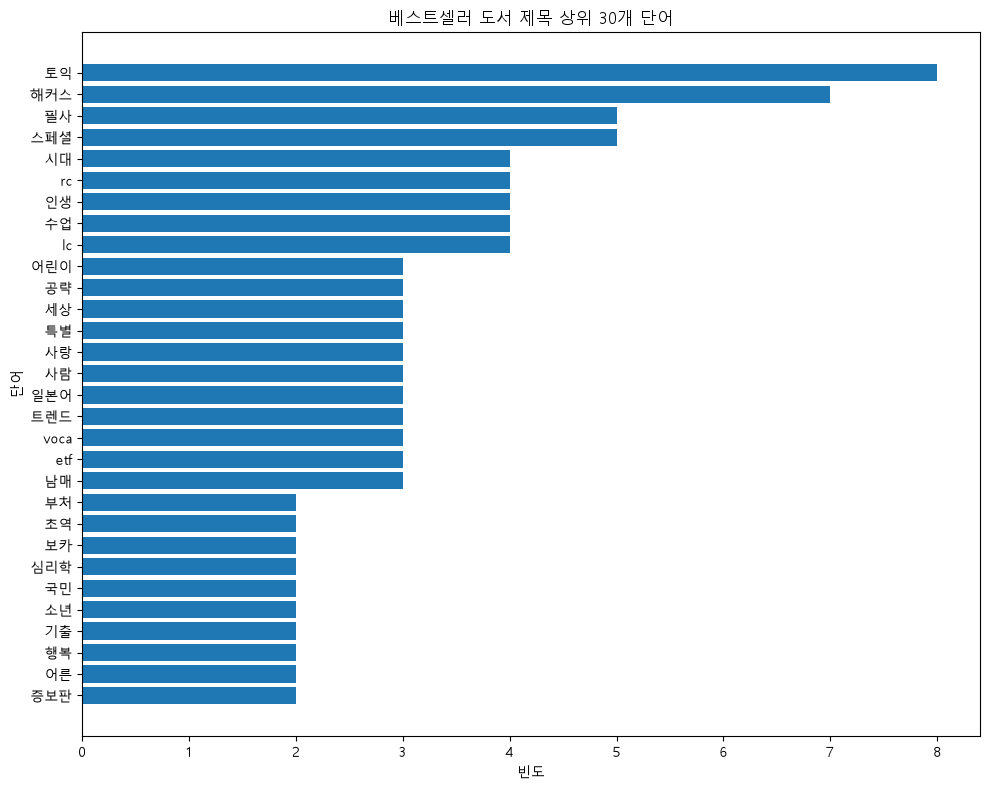

In [31]:
# 그래프를 그리는 라이브러리
import matplotlib.pyplot as plt

# Windows에서 한글이 표시되도록 글꼴 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 가로 막대그래프에서 가장 빈도가 높은 단어가 위에 오도록 정렬
plot_data = top30.sort_values("빈도", ascending=True)

# 그래프 크기 설정
plt.figure(figsize=(10, 8))

# 단어별 빈도를 가로 막대로 표시
plt.barh(plot_data["단어"], plot_data["빈도"])

# 제목과 축 이름
plt.title("베스트셀러 도서 제목 상위 30개 단어")
plt.xlabel("빈도")
plt.ylabel("단어")

# 글자가 잘리지 않도록 배치 조정 후 출력
plt.tight_layout()
plt.show()

### 실습 19. 실행 결과

- 한글이 깨지지 않고 상위 30개 단어가 가로 막대그래프로 표시되었다.
- 가장 빈도가 높은 단어는 `토익` 8회, 다음은 `해커스` 7회로 빈도표와 일치했다.
- 막대 길이로 단어 간 빈도 차이를 확인할 수 있었다.

### 실습 20. Word Cloud 라이브러리 확인

단어 빈도를 Word Cloud로 표현하기 위해 `wordcloud` 라이브러리를 불러올 수 있는지 확인한다.

In [33]:
# Word Cloud를 만드는 기능 불러오기
from wordcloud import WordCloud

# 불러오기에 성공했는지 확인
print("WordCloud 불러오기 성공")

WordCloud 불러오기 성공


### 실습 20. 실행 결과

`wordcloud` 라이브러리를 설치한 뒤 `WordCloud`를 정상적으로 불러왔다.

### 실습 21. Word Cloud용 한글 폰트 확인하기

Word Cloud에 한글 단어를 표시하기 위해 내 컴퓨터에 맑은 고딕 폰트 파일이 있는지 확인한다.

In [34]:
# 파일 경로와 존재 여부를 확인하는 기능
from pathlib import Path

# Windows의 맑은 고딕 폰트 경로
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

# 폰트 파일이 실제로 있는지 확인
print("폰트 경로:", FONT_PATH)
print("폰트 파일 존재:", FONT_PATH.exists())

폰트 경로: C:\Windows\Fonts\malgun.ttf
폰트 파일 존재: True


### 실습 21. 실행 결과

`C:/Windows/Fonts/malgun.ttf` 파일이 존재하는 것을 확인했다. Word Cloud를 만들 때 이 한글 폰트를 사용한다.

### 실습 22. 도서 제목 단어 Word Cloud 만들기

불용어를 적용한 최종 단어 빈도로 Word Cloud를 만든다. 자주 나온 단어가 더 크게 표시되는지 확인하고 이미지 파일로 저장한다.

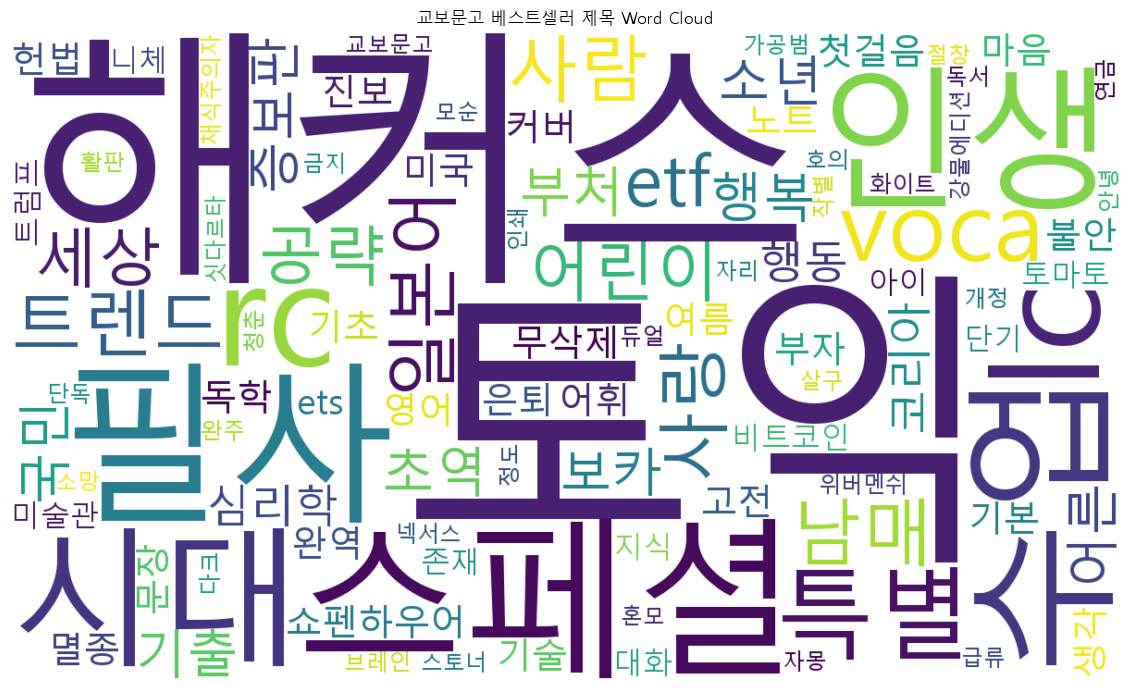

In [35]:
# 최종 단어 빈도(final_counter)로 Word Cloud 생성
wordcloud = WordCloud(
    font_path=str(FONT_PATH),   # 확인한 한글 폰트
    width=1200,                 # 이미지 너비
    height=700,                 # 이미지 높이
    background_color="white",   # 배경색
    max_words=100,              # 최대 표시 단어 수
    random_state=42,            # 다시 실행해도 배치가 같도록 설정
).generate_from_frequencies(final_counter)

# 노트북 화면에 Word Cloud 표시
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 눈금과 테두리 제거
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

In [36]:
# 현재 노트북의 작업 폴더에 이미지 저장
wordcloud.to_file("chapter02_wordcloud.png")

# 파일이 생성되었는지 확인
print("이미지 저장 완료:", Path("chapter02_wordcloud.png").exists())

이미지 저장 완료: True


### 실습 22. 실행 결과

최종 단어 빈도(`final_counter`)로 Word Cloud를 만들고 `chapter02_wordcloud.png` 파일로 저장했다. 파일 존재 여부를 확인한 결과 `True`가 나왔다.

### 실습 23. Word Cloud 해석

이번 Word Cloud에서 글자가 클수록 설정한 분석 조건에서 해당 단어가 더 자주 등장했다는 뜻이다. 빈도표에서는 `토익`이 8회, `해커스`가 7회로 확인되었다.

이는 분석한 도서 **제목**에 그 단어가 자주 나왔다는 의미다. 해당 분야의 판매량이나 독자의 선호도를 이 결과만으로 판단할 수는 없다.

### 실습 24. 상위 단어를 원본 제목에서 확인하기

최종 빈도표의 첫 번째 단어가 원본 도서 제목에서 어떻게 사용되었는지 확인한다. 제목과 분야를 함께 보고 단어의 의미를 살펴본다.

In [37]:
# 최종 빈도표에서 첫 번째 단어 선택
target_word = top30.iloc[0]["단어"]
print("확인할 단어:", target_word)
print("Kiwi로 집계한 빈도:", top30.iloc[0]["빈도"])

# 원본 상품명에 해당 글자가 포함된 행 찾기
matched_titles = df_books.loc[
    df_books["상품명"].astype(str).str.contains(
        str(target_word),
        case=False,
        na=False,
        regex=False
    ),
    ["상품명", "분야"]
]

# 제목과 분야 확인
matched_titles.head(20)

확인할 단어: 토익
Kiwi로 집계한 빈도: 8


,상품명,분야
12,해커스 토익 기출 VOCA(보카),외국어
72,ETS 토익기출 파트별 VOCA,외국어
83,한 권으로 끝내는 해커스 토익 700+(LC+RC+VOCA),외국어
88,해커스 토익 RC Reading(리딩) 기본서,외국어
106,2026 제이크쌤의 28시간에 끝내는 토익스피킹 All in One,외국어
136,해커스 토익 LC Listening(리스닝) 기본서,외국어
153,토익 단기공략 750+(LC+RC),외국어
171,ETS 토익 단기공략 850+(LC+RC),외국어


### 실습 24. 실행 결과

- 최종 빈도표의 첫 번째 단어는 `토익`이며, Kiwi 집계 빈도는 8회였다.
- 원본 제목에서 `토익`이 포함된 도서 8개를 확인했다.
- 확인한 도서의 분야는 모두 `외국어`였다.
- 이번 단어는 제목 검색 결과와 Kiwi 집계 빈도가 같았지만, 다른 단어에서도 항상 일치한다는 뜻은 아니다.

### 실습 25. 단어 빈도 계산 검증하기

`Counter`의 상위 10개 결과와 빈도표의 상위 10개를 비교한다. 전체 빈도 합계가 최종 단어 목록의 길이와 같은지도 확인한다.

In [38]:
# Counter에서 가장 빈도가 높은 단어 10개
counter_top10 = final_counter.most_common(10)

# DataFrame에서 앞의 10행을 같은 형태로 가져오기
table_top10 = top30.head(10).values.tolist()

# 두 결과 비교
print("Counter 상위 10개:", counter_top10)
print("빈도표 상위 10개:", table_top10)
print("상위 10개 일치:", [list(item) for item in counter_top10] == table_top10)

# 모든 단어의 빈도 합과 실제 단어 목록 길이 비교
frequency_total = sum(final_counter.values())
word_count = len(final_words)

print("Counter 전체 빈도 합:", frequency_total)
print("최종 단어 목록 길이:", word_count)
print("전체 개수 일치:", frequency_total == word_count)

Counter 상위 10개: [('토익', 8), ('해커스', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]
빈도표 상위 10개: [['토익', 8], ['해커스', 7], ['스페셜', 5], ['필사', 5], ['인생', 4], ['수업', 4], ['시대', 4], ['lc', 4], ['rc', 4], ['특별', 3]]
상위 10개 일치: True
Counter 전체 빈도 합: 429
최종 단어 목록 길이: 429
전체 개수 일치: True


### 실습 25. 검증 결과

- `Counter`와 빈도표의 상위 10개 단어·빈도가 같은 것을 확인했다.
- `Counter`의 전체 빈도 합과 최종 단어 목록의 길이가 모두 429로 일치했다.
- 따라서 단어 목록을 빈도표로 만드는 과정에서 개수가 누락되거나 추가되지 않았음을 확인했다.

### 실습 26. 불용어 적용 전후 비교하기

불용어 적용 전후의 상위 20개 단어를 나란히 비교한다. 제외한 단어가 빠졌는지, 순위에 어떤 변화가 생겼는지 확인한다.

In [39]:
# 불용어 적용 전 상위 20개
before_top20 = pd.DataFrame(
    noun_counter.most_common(20),
    columns=["적용 전 단어", "적용 전 빈도"]
)

# 불용어 적용 후 상위 20개
after_top20 = pd.DataFrame(
    final_counter.most_common(20),
    columns=["적용 후 단어", "적용 후 빈도"]
)

# 같은 순위끼리 나란히 표시
comparison = pd.concat([before_top20, after_top20], axis=1)

# 비교표 확인
comparison

,적용 전 단어,적용 전 빈도,적용 후 단어,적용 후 빈도
0,에디션,14,토익,8
1,기념,10,해커스,7
2,토익,8,스페셜,5
3,해커스,7,필사,5
4,리커버,7,인생,4
5,스페셜,5,수업,4
6,필사,5,시대,4
7,인생,4,lc,4
8,수업,4,rc,4
9,시대,4,특별,3


### 실습 26. 실행 결과

- 불용어 적용 전 상위에 있던 `에디션` 14회, `기념` 10회, `리커버` 7회, `한정판` 3회가 적용 후 상위 20개에서 사라졌다.
- `토익`의 빈도는 8회로 같지만 순위는 3위에서 1위로 바뀌었다.
- `해커스`도 빈도 7회는 그대로이고 순위가 4위에서 2위로 바뀌었다.
- 불용어를 제외하면서 다른 단어의 등장 횟수가 늘어난 것은 아니고, 표시되는 순위가 달라졌다.

### 실습 27. 결과 해석 초안

교보문고 베스트셀러 도서 제목에서 Kiwi로 일반 명사, 고유 명사, 영문 표현을 추출했다. 2글자 이상 단어를 사용하고 확인한 불용어를 제외한 결과, `토익`이 8회, `해커스`가 7회로 가장 많이 나타났다. 그다음은 `스페셜`과 `필사`가 각각 5회였다. 불용어 적용 전후를 비교하면 제외한 단어는 상위 목록에서 빠졌지만, 남은 단어의 빈도 자체는 변하지 않았다. 이 결과는 분석한 **도서 제목에서의 등장 횟수**이며, 판매 원인이나 독자 선호를 설명하지는 않는다.

## Chapter 02. 도서 제목 단어 빈도 분석 결과

교보문고 베스트셀러 도서 199개의 `상품명`을 분석했다. Kiwi 형태소 분석기로 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)을 추출하고, 2글자 이상인 단어만 사용했다. 원본 제목을 확인한 뒤 `에디션`, `기념`, `리커버`, `한정판`을 불용어로 제외했다.

불용어 적용 전에는 단어 463개, 적용 후에는 429개가 추출되었다. 최종 빈도는 `토익` 8회, `해커스` 7회, `스페셜`과 `필사`가 각각 5회였다. `Counter`와 빈도표의 상위 10개가 일치했고, 전체 빈도 합도 최종 단어 수인 429개와 일치했다. Word Cloud 이미지는 `chapter02_wordcloud.png`로 저장했다.

이 결과는 수집한 **도서 제목에 등장한 단어의 빈도**를 보여준다. 판매 원인이나 독자 선호를 판단할 수는 없다. 또한 `스페셜`, `증보판`, `강물에디션`처럼 판본 관련 표현이 일부 남아 있고, 형태소 분석 결과도 원본 제목의 의미와 다를 수 있다.

### 실습 29. 전체 분석 흐름 재현하기

전처리 CSV를 다시 불러와 제목 준비, Kiwi 분석, 불용어 제거, 빈도 집계, 결과 저장까지 한 번에 실행한다. 앞에서 확인한 최종 단어 수 429개와 상위 단어가 다시 나오는지 검증한다.

In [40]:
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi
from wordcloud import WordCloud

# 1. 전처리한 데이터 다시 불러오기
df_books = pd.read_csv(
    "book_bestseller_clean.csv",
    encoding="utf-8-sig"
)

# 2. 상품명의 빈 값과 앞뒤 공백 정리
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)
titles = titles[titles != ""]

# 3. 형태소 분석기와 추출 조건 준비
kiwi = Kiwi()
TARGET_TAGS = {"NNG", "NNP", "SL"}
MIN_LENGTH = 2

# 원본 제목을 확인한 뒤 선택한 불용어
STOPWORDS = {"에디션", "기념", "리커버", "한정판"}

# 4. 제목에서 조건에 맞는 단어만 추출하는 함수
def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):
        # 지정한 품사가 아니면 제외
        if token.tag not in TARGET_TAGS:
            continue

        # 공백과 영문 대소문자 정리
        word = token.form.strip().lower()

        # 두 글자 미만이면 제외
        if len(word) < MIN_LENGTH:
            continue

        # 불용어에 포함되면 제외
        if word in STOPWORDS:
            continue

        result.append(word)

    return result

# 5. 모든 도서 제목에서 단어 추출
final_words = []
for title in titles:
    final_words.extend(extract_words(title))

# 6. 단어별 빈도 계산과 상위 30개 표 만들기
final_counter = Counter(final_words)
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 상위 30개 표를 CSV 파일로 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)

# 7. 한글 폰트 확인 후 Word Cloud 만들기
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
if not FONT_PATH.exists():
    raise FileNotFoundError(f"한글 폰트가 없습니다: {FONT_PATH}")

wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

# Word Cloud 이미지 저장
wordcloud.to_file("chapter02_wordcloud.png")

# 8. 앞의 실습 결과와 같은지 확인
print("사용한 제목 수:", len(titles))
print("최종 단어 수:", len(final_words))
print("전체 빈도 합:", sum(final_counter.values()))
print("상위 10개:", final_counter.most_common(10))
print("CSV 저장:", Path("chapter02_top30_words.csv").exists())
print("이미지 저장:", Path("chapter02_wordcloud.png").exists())

display(top30)

사용한 제목 수: 199
최종 단어 수: 429
전체 빈도 합: 429
상위 10개: [('토익', 8), ('해커스', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3)]
CSV 저장: True
이미지 저장: True


,단어,빈도
0,토익,8
1,해커스,7
2,스페셜,5
3,필사,5
4,인생,4
5,수업,4
6,시대,4
7,lc,4
8,rc,4
9,특별,3


### 실습 29. 재실행 결과

전체 분석 코드를 다시 실행한 결과, 사용한 제목은 199개이고 최종 단어 수와 전체 빈도 합은 모두 429였다. 상위 단어도 `토익` 8회, `해커스` 7회로 앞선 결과와 일치했다. `chapter02_top30_words.csv`와 `chapter02_wordcloud.png`의 저장 여부도 모두 `True`로 확인했다.

### 실습 30. 오류가 발생했을 때 확인할 순서

1. 처음 오류가 발생한 셀을 찾는다.
2. 오류 메시지의 마지막 줄에서 오류 종류를 확인한다.
3. 파일 오류라면 현재 작업 폴더와 CSV 파일 위치를 확인한다.
4. 컬럼 오류라면 실제 컬럼 이름에 `상품명`이 있는지 확인한다.
5. 라이브러리 오류라면 노트북이 사용하는 Python 환경에 설치되었는지 확인한다.
6. 확인한 코드와 오류 메시지를 바탕으로 문제가 난 부분만 수정한다.

이번 재실행에서는 오류가 발생하지 않았다.

### 실습 31. 예상과 다른 단어 확인하기

최종 단어 목록에서 `혼모`, `강물에디션`처럼 의미를 확인할 필요가 있는 표현을 발견했다. 원본 제목과 Kiwi의 품사 분석 결과를 비교해 해당 단어가 어떻게 추출됐는지 확인한다.

In [41]:
# 결과를 확인하고 싶은 원본 제목의 일부
check_words = ["혼모노", "강물에디션"]

for check_word in check_words:
    # 해당 글자가 포함된 원본 제목 찾기
    matched = df_books.loc[
        df_books["상품명"].astype(str).str.contains(
            check_word,
            regex=False,
            na=False
        ),
        "상품명"
    ]

    # 찾은 제목을 하나씩 분석
    for title in matched:
        print("\n원본 제목:", title)

        # Kiwi가 나눈 단어와 품사 확인
        print("Kiwi 분석:")
        for token in kiwi.tokenize(title):
            print(" ", token.form, token.tag)

        # 현재 조건을 적용한 최종 추출 결과 확인
        print("최종 추출:", extract_words(title))


원본 제목: 혼모노
Kiwi 분석:
  혼모 NNG
  노 NNG
최종 추출: ['혼모']

원본 제목: 단 한 번의 삶(강물에디션 활판인쇄 한정판)
Kiwi 분석:
  단 MM
  한 MM
  번 NNB
  의 JKG
  삶 NNG
  ( SSO
  강물에디션 NNP
  활판 NNG
  인쇄 NNG
  한정판 NNP
  ) SSC
최종 추출: ['강물에디션', '활판', '인쇄']


### 실습 31. 확인 결과

- 원본 제목 `혼모노`를 Kiwi가 `혼모/NNG`, `노/NNG`로 나누었다. 최소 2글자 조건을 적용하자 `혼모`만 남았다.
- `강물에디션`은 `NNP`인 하나의 단어로 분석되어 최종 결과에 남았다. 불용어 목록의 `에디션`과 정확히 같은 단어는 아니기 때문이다.
- 따라서 형태소 분석과 불용어 처리가 모든 제목을 의도대로 정리해 주지는 않는다. 결과에서 낯선 단어가 보이면 원본 제목과 품사 분석을 함께 확인해야 한다.

### 실습 32. 분석 조건

- 데이터: `book_bestseller_clean.csv`의 도서 199개
- 분석 컬럼: `상품명`
- 형태소 분석기: Kiwi
- 추출 품사: 일반 명사(`NNG`), 고유 명사(`NNP`), 영문 표현(`SL`)
- 최소 길이: 2글자
- 영문 처리: 소문자로 통일
- 불용어: `에디션`, `기념`, `리커버`, `한정판`
- 빈도 집계: `collections.Counter`
- 최종 단어 수: 429개
- 결과물: `chapter02_top30_words.csv`, `chapter02_wordcloud.png`

`혼모노`처럼 예상과 다르게 나뉘거나 `강물에디션`처럼 붙은 표현이 남을 수 있으므로, 결과 해석 시 원본 제목도 확인한다.

### 실습 33. 전체 재실행 확인

커널을 재시작한 뒤 노트북의 모든 셀을 순서대로 실행한다. 오류 발생 여부와 최종 단어 수, 빈도 합, 결과 파일 저장 여부를 확인한다.

In [42]:
# 분석에 사용한 데이터와 최종 결과 확인
print("도서 제목 수:", len(titles))
print("최종 단어 수:", len(final_words))
print("빈도 합:", sum(final_counter.values()))
print("상위 단어:", final_counter.most_common(1))

# 결과 파일이 현재 작업 폴더에 저장됐는지 확인
print("빈도표 CSV:", Path("chapter02_top30_words.csv").exists())
print("Word Cloud 이미지:", Path("chapter02_wordcloud.png").exists())

도서 제목 수: 199
최종 단어 수: 429
빈도 합: 429
상위 단어: [('토익', 8)]
빈도표 CSV: True
Word Cloud 이미지: True


### 실습 33. 전체 재실행 결과

노트북을 처음부터 실행한 뒤 도서 제목 199개, 최종 단어 429개, 전체 빈도 합 429를 확인했다. 가장 많이 나온 단어는 `토익` 8회였고, CSV와 Word Cloud 이미지 파일도 모두 존재했다. 전체 실행 과정에서 오류가 발생하지 않았다.

### 실습 34. 이번 Chapter에서 배운 점

- Dictionary로 같은 단어가 나올 때마다 빈도를 1씩 더하는 원리를 확인했다.
- `Counter`와 pandas의 `value_counts()`로 단어 빈도를 집계했다.
- 단순 문자열 분리에서는 조사나 어미가 붙은 표현을 제대로 묶기 어려웠다.
- Kiwi로 품사를 확인하고 `NNG`, `NNP`, `SL` 중 2글자 이상인 단어를 추출했다.
- 원본 제목을 확인한 뒤 불용어를 선택했고, 적용 전 463개에서 적용 후 429개로 단어 수가 바뀌었다.
- Word Cloud의 글자 크기는 이번 조건에서의 제목 속 등장 빈도를 나타낸다.
- `혼모노`와 `강물에디션` 사례처럼 형태소 분석 결과도 원본 제목과 대조해야 한다.

### 실습 35. 최종 결과물 확인

이번 Chapter의 제출 파일이 모두 있는지 확인하고, 저장된 CSV에 상위 30개 단어가 들어 있는지도 다시 읽어 검증한다.

In [43]:
# 최종 결과물 파일 목록
output_files = [
    "chapter02.ipynb",
    "chapter02_top30_words.csv",
    "chapter02_wordcloud.png",
]

# 파일별 존재 여부 확인
for filename in output_files:
    file_path = Path(filename)
    print(filename, "존재:", file_path.exists())

# 저장된 CSV를 다시 읽어 내용 확인
saved_top30 = pd.read_csv(
    "chapter02_top30_words.csv",
    encoding="utf-8-sig"
)

print("저장된 빈도표 행 수:", len(saved_top30))
print("저장된 빈도표 첫 행:", saved_top30.iloc[0].to_dict())

chapter02.ipynb 존재: True
chapter02_top30_words.csv 존재: True
chapter02_wordcloud.png 존재: True
저장된 빈도표 행 수: 30
저장된 빈도표 첫 행: {'단어': '토익', '빈도': 8}


### 실습 35. 최종 결과물 확인

`chapter02.ipynb`, `chapter02_top30_words.csv`, `chapter02_wordcloud.png` 파일이 모두 존재했다. 저장된 빈도표를 다시 읽어 확인한 결과 30행이었고, 첫 행은 `토익` 8회로 Notebook의 분석 결과와 일치했다.